# MNIST Digit Recognition with pyTorch

TODO: check reproducibility

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

## Dataset

### Load

#### TensorFlow/Keras

In [2]:
from tensorflow.keras.datasets import mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

In [3]:
train_images.shape, train_labels.shape, test_images.shape, test_labels.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [4]:
set([type(train_images), type(train_labels), type(test_images), type(test_labels)])

{numpy.ndarray}

#### Native pyTorch

In [5]:
from torchvision import datasets
from torchvision.transforms import ToTensor


### Prepare

In [6]:
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255
test_images = test_images.reshape((10000, 28 * 28))
test_images = test_images.astype("float32") / 255

In [7]:
sorted(set(test_labels))

[np.uint8(0),
 np.uint8(1),
 np.uint8(2),
 np.uint8(3),
 np.uint8(4),
 np.uint8(5),
 np.uint8(6),
 np.uint8(7),
 np.uint8(8),
 np.uint8(9)]

In [8]:
train_images.shape, train_labels.shape, test_images.shape, test_labels.shape

((60000, 784), (60000,), (10000, 784), (10000,))

In [9]:
X_train = torch.tensor(train_images, dtype=torch.float32)
X_test = torch.tensor(test_images, dtype=torch.float32)
y_train = torch.tensor(train_labels, dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(test_labels, dtype=torch.float32).unsqueeze(1)

In [10]:
print(train_images.shape, X_train.shape)
print(train_labels.shape, y_train.shape)

(60000, 784) torch.Size([60000, 784])
(60000,) torch.Size([60000, 1])


In [11]:
print(test_images.shape, X_test.shape)
print(test_labels.shape, y_test.shape)

(10000, 784) torch.Size([10000, 784])
(10000,) torch.Size([10000, 1])


In [12]:
train_dataset = TensorDataset(X_train, y_train)

In [13]:
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

## Model

### Build (architecture)

In [14]:
#model = nn.Sequential(
#    nn.Linear(28 * 28, 512),
#    nn.ReLU(),
#    nn.Linear(512, 10),
#    nn.Softmax(dim=1)
#)

In [15]:
class MNISTNet(nn.Module):  # MNIST network

    def __init__(self):
        super(MNISTNet, self).__init__()

        self.fc1 = nn.Linear(28 * 28, 512)  # fully connected
        self.fc2 = nn.Linear(512, 10)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.softmax(self.fc2(x), dim=1)

        return x

In [16]:
model = MNISTNet()

### Compile

In [17]:
optimizer = optim.RMSprop(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

### Training loop (fit)

In [ ]:
epochs = 5

for epoch in range(epochs):

    model.train()  # training mode
    running_loss = 0.0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()  # reset all gradients

        preds = model(X_batch)

        ## y_batch.shape = [len_batch, 1] i.e., is a tensor([[1.], ... [8.]])
        ## preds.shape = [len_batch, 10]

        loss = criterion(preds, y_batch.squeeze(-1).long())

        loss.backward()  # backpropagation
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}: Loss was {running_loss / len(train_loader)}")  # average batch loss

Epoch 1: Loss was 1.5663988656326653
Epoch 2: Loss was 1.5129665982748655
Epoch 3: Loss was 1.4993298846775536
Epoch 4: Loss was 1.4908874413606201
Epoch 5: Loss was 1.4853959175061062


## Results

### Evaluation (accuracy)

In [19]:
with torch.no_grad():
    model.eval()  # evaluation mode

    preds = model(X_test)
    loss = criterion(preds, y_test.squeeze(-1).long()).item()

    # pred == real
    equals = model(X_batch).argmax(dim=1, keepdim=True) == y_batch.long()
    equals = equals.squeeze(-1)

    test_acc = equals.sum().item() / len(equals)


print(f"test_acc: {test_acc:.5%}")

test_acc: 97.91667%


### Show

In [20]:
import matplotlib.pyplot as plt

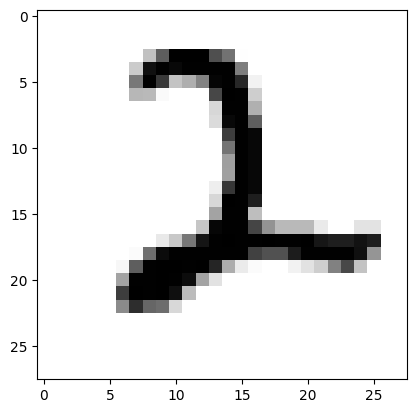

In [21]:
plt.imshow(X_batch[0].reshape(28, 28), cmap="gray_r")